# ✈️ ASG Airlines — End-to-End Data Engineering Pipeline

> **Case Study:** ASG Airlines operates flights across multiple cities and collects operational data from booking platforms, scheduling systems, and airport logs. This notebook implements a complete data engineering pipeline — from raw data ingestion to cleaned, transformed, and aggregated outputs ready for Power BI reporting.

---

## 📋 Pipeline Overview

| Stage | Description |
|-------|-------------|
| **1. Ingestion** | Load raw Excel data, validate schema, run data quality checks |
| **2. Cleaning** | Handle nulls, duplicates, corrupted values, UNKNOWN airlines |
| **3. Transformation** | Standardize times, calculate durations, handle overnight flights |
| **4. PII Masking** | Hash/mask sensitive passenger fields (Aadhaar, email, phone) |
| **5. KPI Aggregation** | Compute business KPIs (avg duration, route traffic, delay flags) |
| **6. Export** | Write cleaned CSVs for Power BI consumption |

---

## 📦 Section 0 — Imports & Setup

In [1]:
# ─── Standard Library ───────────────────────────────────────────────────────
import os
import re
import hashlib
import logging
from datetime import datetime
from pathlib import Path

# ─── Data Processing ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ─── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ─── Warnings ────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ─── Paths ───────────────────────────────────────────────────────────────────
BASE_DIR      = Path('..').resolve()
RAW_DIR       = BASE_DIR / 'data' / 'raw'
CLEANED_DIR   = BASE_DIR / 'data' / 'cleaned'
AGG_DIR       = BASE_DIR / 'data' / 'aggregated'
RAW_FILE      = RAW_DIR / 'UseCase - Airlines.xlsx'

# ─── Logging ─────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%H:%M:%S'
)
log = logging.getLogger('ASG-Pipeline')

# ─── Plot Style ──────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
                     'axes.labelcolor': 'white', 'xtick.color': 'white',
                     'ytick.color': 'white', 'text.color': 'white',
                     'grid.color': '#2e3047', 'axes.titlecolor': 'white'})

log.info('✅ Environment ready. Base dir: %s', BASE_DIR)

23:20:14 | INFO | ✅ Environment ready. Base dir: D:\Desktop\Airline\ASG-Airlines-Pipeline


---
## 🗄️ Section 1 — Data Ingestion

Load all four sheets from the raw Excel file into separate DataFrames and run initial schema and data quality checks.

In [2]:
# ─── 1.1  Load Raw Sheets ────────────────────────────────────────────────────
EXPECTED_SCHEMAS = {
    'flights':    ['flight_id', 'airline', 'source', 'destination', 'departure_time', 'arrival_time'],
    'bookings':   ['booking_id', 'passenger_id', 'flight_id', 'booking_date', 'status', 'passport_number', 'seat_number'],
    'passengers': ['passenger_id', 'first_name', 'last_name', 'age', 'gender', 'email', 'phone', 'aadhaar_id', 'date_of_birth'],
    'payments':   ['payment_id', 'booking_id', 'amount', 'payment_method'],
}

raw = {}
for sheet, expected_cols in EXPECTED_SCHEMAS.items():
    df = pd.read_excel(RAW_FILE, sheet_name=sheet)
    # Keep only expected columns (drop unnamed/extra cols)
    df = df[[c for c in df.columns if not str(c).startswith('Unnamed')]]
    missing_cols = set(expected_cols) - set(df.columns)
    if missing_cols:
        log.warning('⚠️  Sheet [%s] missing expected columns: %s', sheet, missing_cols)
    raw[sheet] = df
    log.info('📥 Loaded [%s]: %d rows × %d cols', sheet, len(df), len(df.columns))

print('\n🗂️  Raw DataFrames loaded:')
for name, df in raw.items():
    print(f'   {name:12s}: {df.shape[0]:>5} rows, {df.shape[1]} columns')

23:20:15 | INFO | 📥 Loaded [flights]: 1020 rows × 7 cols


23:20:16 | INFO | 📥 Loaded [bookings]: 1000 rows × 9 cols


23:20:16 | INFO | 📥 Loaded [passengers]: 1039 rows × 9 cols


23:20:17 | INFO | 📥 Loaded [payments]: 1000 rows × 4 cols



🗂️  Raw DataFrames loaded:
   flights     :  1020 rows, 7 columns
   bookings    :  1000 rows, 9 columns
   passengers  :  1039 rows, 9 columns
   payments    :  1000 rows, 4 columns


In [3]:
# ─── 1.2  Data Quality Report ────────────────────────────────────────────────
def quality_report(df, name):
    """Print a quick data quality summary for a DataFrame."""
    total = len(df)
    print(f'\n━━━ Quality Report: [{name}] ({total} rows) ━━━')
    qdf = pd.DataFrame({
        'dtype':       df.dtypes.astype(str),
        'null_count':  df.isnull().sum(),
        'null_%':      (df.isnull().sum() / total * 100).round(2),
        'unique':      df.nunique(),
        'sample':      df.apply(lambda c: c.dropna().iloc[0] if c.dropna().shape[0] else 'N/A'),
    })
    print(qdf.to_string())
    dupe_count = df.duplicated().sum()
    print(f'   Duplicate rows: {dupe_count}')
    return qdf

for name, df in raw.items():
    quality_report(df, name)


━━━ Quality Report: [flights] (1020 rows) ━━━
                         dtype  null_count  null_%  unique                      sample
flight_id               object           0    0.00    1004                       SJ010
airline                 object          41    4.02       5                    SpiceJet
source                  object           0    0.00       6                         CCU
destination             object           0    0.00       6                         MAA
departure_time  datetime64[ns]           0    0.00     981  2026-04-20 23:38:41.701000
arrival_time    datetime64[ns]           0    0.00     969  2026-04-21 02:32:41.701000
duration                object           0    0.00     270                    02:54:00
   Duplicate rows: 15

━━━ Quality Report: [bookings] (1000 rows) ━━━
                                  dtype  null_count  null_%  unique                      sample
booking_id                       object           0     0.0    1000                       B

In [4]:
# ─── 1.3  Snapshot: Preview Raw Flights ──────────────────────────────────────
print('🔍 Raw Flights (first 10 rows):')
raw['flights'].head(10)

🔍 Raw Flights (first 10 rows):


,flight_id,airline,source,destination,departure_time,arrival_time,duration
0,SJ010,SpiceJet,CCU,MAA,2026-04-20 23:38:41.701,2026-04-21 02:32:41.701,02:54:00
1,AI155,Air India,BOM,CCU,2026-04-20 23:35:41.703,2026-04-21 01:23:41.703,01:48:00
2,UK094,Vistara,BOM,CCU,2026-04-20 23:26:41.702,2026-04-21 01:11:41.702,01:45:00
3,AI245,Air India,BOM,CCU,2026-04-20 23:07:41.704,2026-04-21 01:43:41.704,02:36:00
4,AI192,Air India,MAA,BOM,2026-04-20 23:05:41.703,2026-04-21 04:04:41.703,04:59:00
5,SJ158,SpiceJet,DEL,HYD,2026-04-20 23:05:41.703,2026-04-21 01:24:41.703,02:19:00
6,6F196,IndiGo,CCU,MAA,2026-04-20 23:04:41.703,2026-04-21 00:47:41.703,01:43:00
7,AI080,Air India,BOM,HYD,2026-04-20 23:03:41.702,2026-04-21 00:35:41.702,01:32:00
8,6F025,IndiGo,BLR,BOM,2026-04-20 23:02:41.701,2026-04-20 23:57:41.701,00:55:00
9,6F251,UNKNOWN,DEL,BLR,2026-04-20 22:56:41.703,2026-04-20 23:37:41.703,00:41:00


---
## 🧹 Section 2 — Data Cleaning & Transformation

### Cleaning Strategy

| Issue | Handling |
|-------|----------|
| Extra / unnamed columns | Dropped during ingestion |
| `duration` column (Excel formula strings) | Recalculated in Python |
| `UNKNOWN` airline values | Flagged; imputed using flight_id prefix if possible, else kept flagged |
| Duplicate flight records | Deduplicated (first occurrence kept) |
| Missing departure/arrival times | Rows dropped (cannot derive duration) |
| Missing source/destination | Rows dropped (cannot route-classify) |
| Overnight flights (arrival next day) | Handled correctly in duration calc — no +24h adjustment needed |
| Passenger PII (Aadhaar, email, phone) | SHA-256 hashed |

In [5]:
# ─── 2.1  Clean Flights ──────────────────────────────────────────────────────
flights = raw['flights'].copy()

# Step 1: Drop the Excel formula duration column and unnamed cols
drop_cols = [c for c in flights.columns if str(c).startswith('Unnamed') or c == 'duration']
flights.drop(columns=drop_cols, errors='ignore', inplace=True)
log.info('Dropped Excel formula columns: %s', drop_cols)

# Step 2: Rename columns — ensure standard names
flights.columns = ['flight_id', 'airline', 'source', 'destination', 'departure_time', 'arrival_time']

# Step 3: Strip whitespace from string columns
str_cols = ['flight_id', 'airline', 'source', 'destination']
for col in str_cols:
    flights[col] = flights[col].astype(str).str.strip().str.upper()

# Step 4: Parse datetime columns
flights['departure_time'] = pd.to_datetime(flights['departure_time'], errors='coerce')
flights['arrival_time']   = pd.to_datetime(flights['arrival_time'],   errors='coerce')

print(f'Before cleaning: {len(flights)} rows')

# Step 5: Drop rows with null critical fields
before = len(flights)
critical_cols = ['flight_id', 'source', 'destination', 'departure_time', 'arrival_time']
flights.dropna(subset=critical_cols, inplace=True)
log.info('Dropped %d rows with null critical fields', before - len(flights))

# Step 6: Remove full duplicates
before = len(flights)
flights.drop_duplicates(inplace=True)
log.info('Dropped %d fully duplicate rows', before - len(flights))

# Step 7: Remove duplicate flight_ids (keep first)
before = len(flights)
flights.drop_duplicates(subset=['flight_id'], keep='first', inplace=True)
log.info('Dropped %d duplicate flight_id rows', before - len(flights))

# Step 8: Validate arrival > departure (drop invalid)
invalid_time = flights['arrival_time'] <= flights['departure_time']
log.info('Records with arrival <= departure: %d', invalid_time.sum())
flights = flights[~invalid_time]

# Step 9: Handle UNKNOWN airline — try to impute from flight_id prefix
AIRLINE_PREFIX_MAP = {
    'AI': 'Air India',
    'SJ': 'SpiceJet',
    '6F': 'IndiGo',
    'UK': 'Vistara',
    'G8': 'Go First',
}

def impute_airline(row):
    if row['airline'] == 'UNKNOWN':
        prefix = str(row['flight_id'])[:2]
        return AIRLINE_PREFIX_MAP.get(prefix, 'UNKNOWN')
    return row['airline']

before_unknown = (flights['airline'] == 'UNKNOWN').sum()
flights['airline'] = flights.apply(impute_airline, axis=1)
after_unknown  = (flights['airline'] == 'UNKNOWN').sum()
log.info('Imputed airline for %d UNKNOWN records; %d remain UNKNOWN',
         before_unknown - after_unknown, after_unknown)

print(f'After cleaning: {len(flights)} rows')
flights.head()

23:20:17 | INFO | Dropped Excel formula columns: ['duration']


Before cleaning: 1020 rows


23:20:17 | INFO | Dropped 0 rows with null critical fields


23:20:17 | INFO | Dropped 15 fully duplicate rows


23:20:17 | INFO | Dropped 1 duplicate flight_id rows


23:20:17 | INFO | Records with arrival <= departure: 1


23:20:17 | INFO | Imputed airline for 29 UNKNOWN records; 0 remain UNKNOWN


After cleaning: 1003 rows


,flight_id,airline,source,destination,departure_time,arrival_time
0,SJ010,SPICEJET,CCU,MAA,2026-04-20 23:38:41.701,2026-04-21 02:32:41.701
1,AI155,AIR INDIA,BOM,CCU,2026-04-20 23:35:41.703,2026-04-21 01:23:41.703
2,UK094,VISTARA,BOM,CCU,2026-04-20 23:26:41.702,2026-04-21 01:11:41.702
3,AI245,AIR INDIA,BOM,CCU,2026-04-20 23:07:41.704,2026-04-21 01:43:41.704
4,AI192,AIR INDIA,MAA,BOM,2026-04-20 23:05:41.703,2026-04-21 04:04:41.703


In [6]:
# ─── 2.2  Duration Calculation (Overnight-Aware) ──────────────────────────────
#
# Overnight flights: arrival_time datetime is already the NEXT calendar day,
# so simple subtraction naturally gives the correct duration (no +24h hack needed).
# We calculate duration in minutes for easier aggregation.

flights['duration_mins'] = (
    (flights['arrival_time'] - flights['departure_time'])
    .dt.total_seconds() / 60
).round(2)

# Flag overnight flights (arrival on a different calendar day than departure)
flights['is_overnight'] = (
    flights['arrival_time'].dt.date > flights['departure_time'].dt.date
).astype(int)

# Sanity check: duration should be > 0 and < 24 hours (1440 mins)
unrealistic = flights[(flights['duration_mins'] <= 0) | (flights['duration_mins'] > 1440)]
log.info('Unrealistic durations: %d rows', len(unrealistic))

flights = flights[(flights['duration_mins'] > 0) & (flights['duration_mins'] <= 1440)]

# Human-readable duration string
flights['duration_hhmm'] = flights['duration_mins'].apply(
    lambda m: f"{int(m)//60}h {int(m)%60}m"
)

print(f'✅ Duration calculated for {len(flights)} flights')
print(f'   Overnight flights: {flights["is_overnight"].sum()}')
print(f'   Avg duration: {flights["duration_mins"].mean():.1f} mins')
flights[['flight_id', 'departure_time', 'arrival_time', 'duration_mins', 'duration_hhmm', 'is_overnight']].head(10)

23:20:17 | INFO | Unrealistic durations: 0 rows


✅ Duration calculated for 1003 flights
   Overnight flights: 122
   Avg duration: 164.6 mins


,flight_id,departure_time,arrival_time,duration_mins,duration_hhmm,is_overnight
0,SJ010,2026-04-20 23:38:41.701,2026-04-21 02:32:41.701,174.0,2h 54m,1
1,AI155,2026-04-20 23:35:41.703,2026-04-21 01:23:41.703,108.0,1h 48m,1
2,UK094,2026-04-20 23:26:41.702,2026-04-21 01:11:41.702,105.0,1h 45m,1
3,AI245,2026-04-20 23:07:41.704,2026-04-21 01:43:41.704,156.0,2h 36m,1
4,AI192,2026-04-20 23:05:41.703,2026-04-21 04:04:41.703,299.0,4h 59m,1
5,SJ158,2026-04-20 23:05:41.703,2026-04-21 01:24:41.703,139.0,2h 19m,1
6,6F196,2026-04-20 23:04:41.703,2026-04-21 00:47:41.703,103.0,1h 43m,1
7,AI080,2026-04-20 23:03:41.702,2026-04-21 00:35:41.702,92.0,1h 32m,1
8,6F025,2026-04-20 23:02:41.701,2026-04-20 23:57:41.701,55.0,0h 55m,0
9,6F251,2026-04-20 22:56:41.703,2026-04-20 23:37:41.703,41.0,0h 41m,0


In [7]:
# ─── 2.3  Derive Additional Features ─────────────────────────────────────────

# Route column
flights['route'] = flights['source'] + ' to ' + flights['destination']

# Time-of-day bucket for departure
def time_bucket(dt):
    h = dt.hour
    if 5 <= h < 9:   return 'Early Morning'
    if 9 <= h < 12:  return 'Morning'
    if 12 <= h < 17: return 'Afternoon'
    if 17 <= h < 21: return 'Evening'
    return 'Night'

flights['departure_slot'] = flights['departure_time'].apply(time_bucket)

# Delay flag — heuristic: duration_mins > route_avg * 1.30 (30% over average)
route_avg = flights.groupby('route')['duration_mins'].transform('mean')
flights['is_delayed'] = (flights['duration_mins'] > route_avg * 1.30).astype(int)

# Departure / Arrival date columns
flights['departure_date'] = flights['departure_time'].dt.date
flights['arrival_date']   = flights['arrival_time'].dt.date
flights['departure_hour'] = flights['departure_time'].dt.hour

print(f'\n✅ Feature engineering complete')
print(f'   Delayed flights flagged: {flights["is_delayed"].sum()}')
print(f'   Departure slots: {flights["departure_slot"].value_counts().to_dict()}')
flights.head(3)


✅ Feature engineering complete
   Delayed flights flagged: 314
   Departure slots: {'Night': 319, 'Afternoon': 267, 'Evening': 171, 'Early Morning': 132, 'Morning': 114}


,flight_id,airline,source,destination,departure_time,arrival_time,duration_mins,is_overnight,duration_hhmm,route,departure_slot,is_delayed,departure_date,arrival_date,departure_hour
0,SJ010,SPICEJET,CCU,MAA,2026-04-20 23:38:41.701,2026-04-21 02:32:41.701,174.0,1,2h 54m,CCU to MAA,Night,0,2026-04-20,2026-04-21,23
1,AI155,AIR INDIA,BOM,CCU,2026-04-20 23:35:41.703,2026-04-21 01:23:41.703,108.0,1,1h 48m,BOM to CCU,Night,0,2026-04-20,2026-04-21,23
2,UK094,VISTARA,BOM,CCU,2026-04-20 23:26:41.702,2026-04-21 01:11:41.702,105.0,1,1h 45m,BOM to CCU,Night,0,2026-04-20,2026-04-21,23


In [8]:
# ─── 2.4  Clean Passengers ───────────────────────────────────────────────────
passengers = raw['passengers'].copy()

# Standardize
passengers['passenger_id'] = passengers['passenger_id'].astype(str).str.strip()
passengers['gender'] = passengers['gender'].astype(str).str.upper().str.strip()
passengers['email']  = passengers['email'].astype(str).str.lower().str.strip()
passengers['date_of_birth'] = pd.to_datetime(passengers['date_of_birth'], errors='coerce')

# Drop full duplicates
before = len(passengers)
passengers.drop_duplicates(inplace=True)
log.info('Passengers: dropped %d duplicates', before - len(passengers))

print(f'Passengers cleaned: {len(passengers)} rows')
passengers.head(3)

23:20:17 | INFO | Passengers: dropped 0 duplicates


Passengers cleaned: 1039 rows


,passenger_id,first_name,last_name,age,gender,email,phone,aadhaar_id,date_of_birth
0,P1000,Vivaan,Chatterjee,52,F,vivaan.chatterjee@gmail.com,+91-6896233790,433218196001,1974-04-08
1,P1001,Krishna,Reddy,15,M,krishna.reddy@hotmail.com,+91-6702632297,386379402654,2011-03-07
2,P1002,Myra,Naidu,72,M,myra.naidu@outlook.com,+91-6199585092,615594078161,1954-09-10


In [9]:
# ─── 2.5  Clean Bookings ─────────────────────────────────────────────────────
bookings = raw['bookings'].copy()

# Keep only expected columns
bookings = bookings[['booking_id', 'passenger_id', 'flight_id', 'booking_date', 'status',
                     'passport_number', 'seat_number', 'emergency_contact_name', 'emergency_contact_phone']]

# Standardize
bookings['booking_id']   = bookings['booking_id'].astype(str).str.strip()
bookings['passenger_id'] = bookings['passenger_id'].astype(str).str.strip()
bookings['flight_id']    = bookings['flight_id'].astype(str).str.strip().str.upper()
bookings['status']       = bookings['status'].astype(str).str.upper().str.strip()
bookings['booking_date'] = pd.to_datetime(bookings['booking_date'], errors='coerce')

before = len(bookings)
bookings.drop_duplicates(inplace=True)
log.info('Bookings: dropped %d duplicates', before - len(bookings))

print(f'Bookings cleaned: {len(bookings)} rows')
print(f'   Status distribution: {bookings["status"].value_counts().to_dict()}')
bookings.head(3)

23:20:17 | INFO | Bookings: dropped 0 duplicates


Bookings cleaned: 1000 rows
   Status distribution: {'CONFIRMED': 320, 'CANCELLED': 314, 'PENDING': 291, 'NAN': 45, 'INVALID': 30}


,booking_id,passenger_id,flight_id,booking_date,status,passport_number,seat_number,emergency_contact_name,emergency_contact_phone
0,B1000,P1591,AI192,2025-06-14 11:37:36.951,CANCELLED,P1945887,3D,Isaac Bakshi,+91-6478475128
1,B1001,P1803,6F026,2025-11-02 11:37:36.951,CANCELLED,L3482012,18A,Anvi Konda,+91-6647078662
2,B1002,P1083,SJ010,2025-08-25 11:37:36.951,CANCELLED,G8507659,30C,Udant Dewan,+91-8405938220


In [10]:
# ─── 2.6  Clean Payments ─────────────────────────────────────────────────────
payments = raw['payments'].copy()
payments['payment_id']    = payments['payment_id'].astype(str).str.strip()
payments['booking_id']    = payments['booking_id'].astype(str).str.strip()
payments['payment_method']= payments['payment_method'].astype(str).str.upper().str.strip()
payments['amount']        = pd.to_numeric(payments['amount'], errors='coerce')

before = len(payments)
payments.drop_duplicates(inplace=True)
payments.dropna(subset=['amount'], inplace=True)
log.info('Payments: kept %d / %d rows', len(payments), before)

print(f'Payments cleaned: {len(payments)} rows')
payments.head(3)

23:20:17 | INFO | Payments: kept 922 / 1000 rows


Payments cleaned: 922 rows


,payment_id,booking_id,amount,payment_method
0,PAY1000,B1116,9883.49,NETBANKING
1,PAY1001,B1738,8457.96,NETBANKING
2,PAY1002,B1873,6495.37,UPI


---
## 🔐 Section 3 — PII Masking

The passenger table contains sensitive personal data:

| Field | Classification | Action |
|-------|---------------|--------|
| `aadhaar_id` | **Highly Sensitive** | SHA-256 hashed |
| `email` | **Sensitive** | SHA-256 hashed |
| `phone` | **Sensitive** | SHA-256 hashed |
| `first_name`, `last_name` | **PII** | Pseudonymised (first letter + ***) |
| `date_of_birth` | **PII** | Year only retained |
| `passport_number` (bookings) | **Highly Sensitive** | SHA-256 hashed |
| `emergency_contact_phone` (bookings) | **Sensitive** | SHA-256 hashed |

In [11]:
# ─── 3.1  PII Masking Utilities ───────────────────────────────────────────────
SALT = 'ASG_AIRLINES_2026_SECURE_SALT'

def sha256_hash(value: str) -> str:
    """SHA-256 hash with a secret salt — one-way, irreversible."""
    if pd.isna(value) or str(value).strip() in ('', 'nan', 'None'):
        return None
    salted = f"{SALT}:{value}"
    return hashlib.sha256(salted.encode()).hexdigest()

def pseudonymise_name(value: str) -> str:
    """Retain first letter and mask the rest."""
    if pd.isna(value) or len(str(value)) == 0:
        return '***'
    return str(value)[0] + '***'

# ─── 3.2  Apply Masking to Passengers ────────────────────────────────────────
pax_masked = passengers.copy()

pax_masked['aadhaar_id_hash']  = pax_masked['aadhaar_id'].astype(str).apply(sha256_hash)
pax_masked['email_hash']       = pax_masked['email'].astype(str).apply(sha256_hash)
pax_masked['phone_hash']       = pax_masked['phone'].astype(str).apply(sha256_hash)
pax_masked['first_name_masked']= pax_masked['first_name'].apply(pseudonymise_name)
pax_masked['last_name_masked'] = pax_masked['last_name'].apply(pseudonymise_name)
pax_masked['birth_year']       = pax_masked['date_of_birth'].dt.year

# Drop raw PII columns
pax_masked.drop(columns=['aadhaar_id', 'email', 'phone', 'first_name', 'last_name', 'date_of_birth'],
                inplace=True)

# ─── 3.3  Apply Masking to Bookings ──────────────────────────────────────────
bk_masked = bookings.copy()
bk_masked['passport_hash']   = bk_masked['passport_number'].astype(str).apply(sha256_hash)
bk_masked['emg_phone_hash']  = bk_masked['emergency_contact_phone'].astype(str).apply(sha256_hash)
bk_masked['emg_name_masked'] = bk_masked['emergency_contact_name'].apply(pseudonymise_name)
bk_masked.drop(columns=['passport_number', 'emergency_contact_phone', 'emergency_contact_name'],
               inplace=True)

print('✅ PII Masking applied')
print('\nPassengers (masked):')
display(pax_masked.head(3))
print('\nBookings (masked):')
display(bk_masked.head(3))

✅ PII Masking applied

Passengers (masked):


,passenger_id,age,gender,aadhaar_id_hash,email_hash,phone_hash,first_name_masked,last_name_masked,birth_year
0,P1000,52,F,551e098472cf9941950ab17bf820035a657a42ac3aafbe...,02e02fca05ad5960dc3343ff8a6d02b1caf37e2cf235e8...,419abdcc12f11f51dc97c52391475e1889700a71b24fd9...,V***,C***,1974
1,P1001,15,M,5fd2ab05337408ca16197b5c205dae54073aa0372e0d00...,2546086d55f0c9a4797c106c634305c4e4594657771a7f...,f2b2771b4034352af5cae090d4e6b069c01957a4385718...,K***,R***,2011
2,P1002,72,M,f49911a3a04818ca8e9e32453f579f10ac2907c93f060c...,6a03b5f51992d75fdce9a71fba34b1a5cdbb1e4588c680...,c8deb9443f875ad1781149b78d480f767296b05413b0b7...,M***,N***,1954



Bookings (masked):


,booking_id,passenger_id,flight_id,booking_date,status,seat_number,passport_hash,emg_phone_hash,emg_name_masked
0,B1000,P1591,AI192,2025-06-14 11:37:36.951,CANCELLED,3D,652f4788875e3ce65d9e1ce2b135153e78c4ad42ec5df0...,5f330beaaf394f963e9937d2148f8fdf89051d4310f769...,I***
1,B1001,P1803,6F026,2025-11-02 11:37:36.951,CANCELLED,18A,6f9874391801195a95bcd1673e3ca0d5f3ecf02f9d0600...,208cc59f5d3e2fd6eb6551e58530942ecb812cbf26b35b...,A***
2,B1002,P1083,SJ010,2025-08-25 11:37:36.951,CANCELLED,30C,442dd481c3c4f8ec14493472239f5f80b4954201229041...,04bc4fe0633286fb857dd4949a18ff32ac5fb892486935...,U***


---
## 📊 Section 4 — Business KPI Calculations

Deriving all required KPIs plus additional insights.

In [12]:
# ─── 4.1  KPI 1: Average Flight Duration ─────────────────────────────────────

overall_avg = flights['duration_mins'].mean()

avg_by_airline = (
    flights.groupby('airline')['duration_mins']
    .agg(['mean', 'min', 'max', 'count'])
    .round(2)
    .rename(columns={'mean': 'avg_duration_mins', 'min': 'min_duration_mins',
                     'max': 'max_duration_mins', 'count': 'flight_count'})
    .reset_index()
    .sort_values('avg_duration_mins', ascending=False)
)

avg_by_route = (
    flights.groupby('route')['duration_mins']
    .agg(['mean', 'count'])
    .round(2)
    .rename(columns={'mean': 'avg_duration_mins', 'count': 'flight_count'})
    .reset_index()
    .sort_values('avg_duration_mins', ascending=False)
)

print(f'📌 Overall Average Flight Duration: {overall_avg:.1f} minutes ({overall_avg/60:.2f} hours)')
print('\nAvg Duration by Airline:')
display(avg_by_airline)
print('\nAvg Duration by Route (Top 10):')
display(avg_by_route.head(10))

📌 Overall Average Flight Duration: 164.6 minutes (2.74 hours)

Avg Duration by Airline:


,airline,avg_duration_mins,min_duration_mins,max_duration_mins,flight_count
8,Vistara,198.75,98.0,278.0,4
1,Air India,172.00,62.0,226.0,8
6,SpiceJet,169.67,87.0,263.0,6
4,NAN,169.54,33.0,291.0,39
2,INDIGO,167.70,30.0,300.0,249
5,SPICEJET,163.61,32.0,300.0,235
0,AIR INDIA,163.15,35.0,299.0,233
7,VISTARA,162.68,30.0,300.0,218
3,IndiGo,147.73,41.0,267.0,11



Avg Duration by Route (Top 10):


,route,avg_duration_mins,flight_count
4,BLR to MAA,187.31,16
23,HYD to DEL,185.36,42
9,BOM to MAA,183.41,27
8,BOM to HYD,180.85,26
19,DEL to MAA,178.78,23
16,DEL to BOM,178.11,28
26,MAA to BOM,176.76,21
5,BOM to BLR,176.52,23
18,DEL to HYD,174.76,54
10,CCU to BLR,174.42,19


In [13]:
# ─── 4.2  KPI 2: Route-wise Traffic ──────────────────────────────────────────

route_traffic = (
    flights.groupby('route')
    .agg(
        flight_count      = ('flight_id', 'count'),
        avg_duration      = ('duration_mins', 'mean'),
        delayed_flights   = ('is_delayed', 'sum'),
        overnight_flights = ('is_overnight', 'sum'),
    )
    .round(2)
    .reset_index()
    .sort_values('flight_count', ascending=False)
)

route_traffic['delay_rate_%'] = (
    route_traffic['delayed_flights'] / route_traffic['flight_count'] * 100
).round(2)

print('📌 Route-wise Traffic (Top 15):')
display(route_traffic.head(15))

📌 Route-wise Traffic (Top 15):


,route,flight_count,avg_duration,delayed_flights,overnight_flights,delay_rate_%
6,BOM to CCU,90,169.51,23,16,25.56
12,CCU to DEL,72,153.61,25,11,34.72
25,MAA to BLR,65,172.82,22,8,33.85
0,BLR to BOM,60,147.73,21,7,35.00
24,HYD to MAA,57,152.81,20,5,35.09
18,DEL to HYD,54,174.76,16,6,29.63
23,HYD to DEL,42,185.36,14,9,33.33
7,BOM to DEL,39,153.82,10,3,25.64
11,CCU to BOM,33,163.97,11,1,33.33
15,DEL to BLR,29,170.03,10,3,34.48


In [14]:
# ─── 4.3  KPI 3: Delay & Anomaly Analysis ────────────────────────────────────

delay_summary = (
    flights.groupby('airline')
    .agg(
        total_flights   = ('flight_id', 'count'),
        delayed_flights = ('is_delayed', 'sum'),
        overnight_count = ('is_overnight', 'sum'),
    )
    .reset_index()
)
delay_summary['delay_rate_%'] = (
    delay_summary['delayed_flights'] / delay_summary['total_flights'] * 100
).round(2)

print('📌 Delay Summary by Airline:')
display(delay_summary)

print(f'\n📌 Total delayed flights: {flights["is_delayed"].sum()}')
print(f'📌 Overall delay rate: {flights["is_delayed"].mean()*100:.1f}%')
print(f'📌 Total overnight flights: {flights["is_overnight"].sum()}')

📌 Delay Summary by Airline:


,airline,total_flights,delayed_flights,overnight_count,delay_rate_%
0,AIR INDIA,233,63,30,27.04
1,Air India,8,2,2,25.00
2,INDIGO,249,89,30,35.74
3,IndiGo,11,4,0,36.36
4,NAN,39,13,4,33.33
5,SPICEJET,235,69,27,29.36
6,SpiceJet,6,1,1,16.67
7,VISTARA,218,71,27,32.57
8,Vistara,4,2,1,50.00



📌 Total delayed flights: 314
📌 Overall delay rate: 31.3%
📌 Total overnight flights: 122


In [15]:
# ─── 4.4  KPI 4: Distribution of Flights by Airline ─────────────────────────

airline_dist = (
    flights.groupby('airline')
    .agg(
        flight_count      = ('flight_id', 'count'),
        avg_duration_mins = ('duration_mins', 'mean'),
        min_duration_mins = ('duration_mins', 'min'),
        max_duration_mins = ('duration_mins', 'max'),
    )
    .round(2)
    .reset_index()
    .sort_values('flight_count', ascending=False)
)
airline_dist['market_share_%'] = (
    airline_dist['flight_count'] / airline_dist['flight_count'].sum() * 100
).round(2)

print('📌 Airline Distribution:')
display(airline_dist)

📌 Airline Distribution:


,airline,flight_count,avg_duration_mins,min_duration_mins,max_duration_mins,market_share_%
2,INDIGO,249,167.70,30.0,300.0,24.83
5,SPICEJET,235,163.61,32.0,300.0,23.43
0,AIR INDIA,233,163.15,35.0,299.0,23.23
7,VISTARA,218,162.68,30.0,300.0,21.73
4,NAN,39,169.54,33.0,291.0,3.89
3,IndiGo,11,147.73,41.0,267.0,1.10
1,Air India,8,172.00,62.0,226.0,0.80
6,SpiceJet,6,169.67,87.0,263.0,0.60
8,Vistara,4,198.75,98.0,278.0,0.40


In [16]:
# ─── 4.5  Additional KPIs ─────────────────────────────────────────────────────

# KPI 5: Revenue by airline (via bookings + payments join)
booking_revenue = bk_masked.merge(payments, on='booking_id', how='left')
booking_revenue_flight = booking_revenue.merge(
    flights[['flight_id', 'airline', 'route']], on='flight_id', how='left'
)

revenue_by_airline = (
    booking_revenue_flight.groupby('airline')['amount']
    .agg(['sum', 'mean', 'count'])
    .rename(columns={'sum': 'total_revenue', 'mean': 'avg_ticket_price', 'count': 'bookings_with_payment'})
    .round(2)
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

# KPI 6: Busiest departure time slot
slot_traffic = flights.groupby('departure_slot')['flight_id'].count().reset_index()
slot_traffic.columns = ['departure_slot', 'flight_count']

# KPI 7: Booking status breakdown
booking_status = bk_masked.groupby('status')['booking_id'].count().reset_index()
booking_status.columns = ['status', 'count']

# KPI 8: Payment method distribution
payment_method_dist = payments.groupby('payment_method')['amount'].agg(['count','sum']).round(2).reset_index()

print('📌 Revenue by Airline:')
display(revenue_by_airline)
print('\n📌 Departure Slot Traffic:')
display(slot_traffic)
print('\n📌 Booking Status Breakdown:')
display(booking_status)
print('\n📌 Payment Method Distribution:')
display(payment_method_dist)

📌 Revenue by Airline:


,airline,total_revenue,avg_ticket_price,bookings_with_payment
7,VISTARA,2045172.43,8557.21,239
5,SPICEJET,1827246.59,7876.06,232
0,AIR INDIA,1617917.09,7667.85,211
2,INDIGO,1477798.71,7902.67,187
4,NAN,245057.22,7658.04,32
6,SpiceJet,53480.09,10696.02,5
3,IndiGo,47045.44,5880.68,8
1,Air India,34960.21,8740.05,4
8,Vistara,21765.10,7255.03,3



📌 Departure Slot Traffic:


,departure_slot,flight_count
0,Afternoon,267
1,Early Morning,132
2,Evening,171
3,Morning,114
4,Night,319



📌 Booking Status Breakdown:


,status,count
0,CANCELLED,314
1,CONFIRMED,320
2,INVALID,30
3,NAN,45
4,PENDING,291



📌 Payment Method Distribution:


,payment_method,count,sum
0,CARD,300,2400812.04
1,NETBANKING,291,2365644.17
2,UPI,331,2618686.77


---
## 📈 Section 5 — Exploratory Visualisations

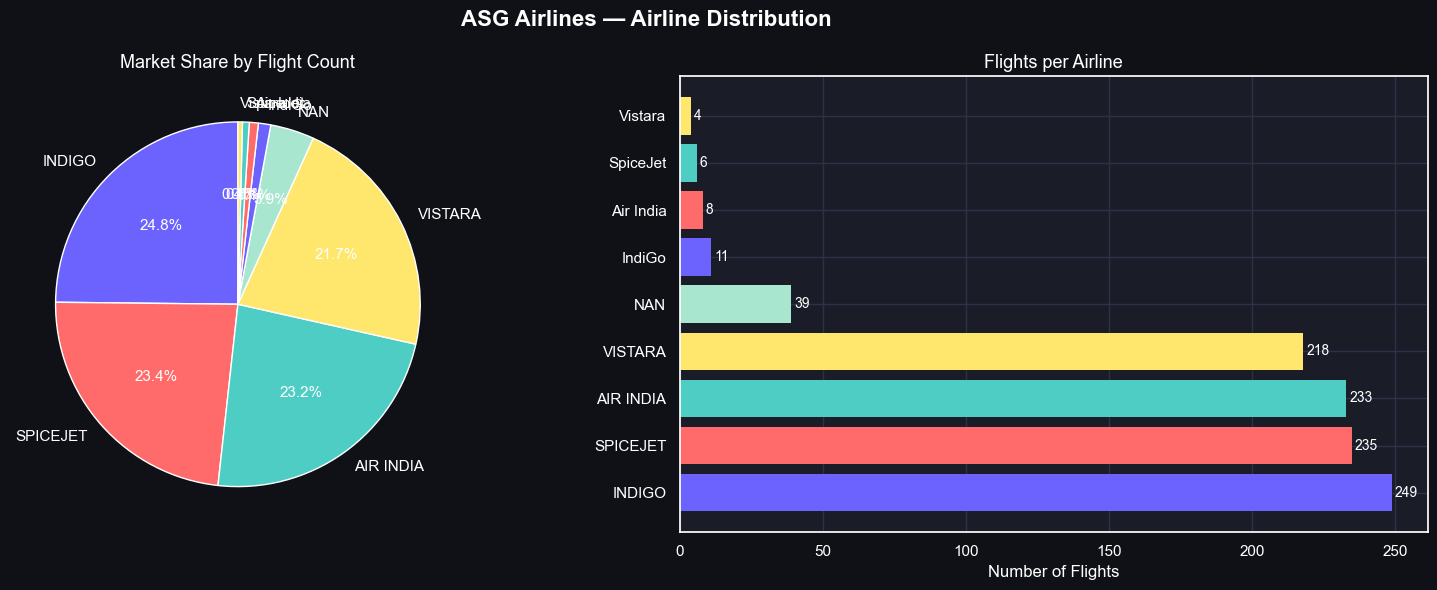

In [17]:
# ─── 5.1  Airline Market Share ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ASG Airlines — Airline Distribution', fontsize=16, fontweight='bold', color='white')

COLORS = ['#6C63FF', '#FF6B6B', '#4ECDC4', '#FFE66D', '#A8E6CF']

# Pie chart
ax = axes[0]
ax.pie(airline_dist['flight_count'], labels=airline_dist['airline'],
       autopct='%1.1f%%', colors=COLORS, startangle=90,
       textprops={'color': 'white', 'fontsize': 11})
ax.set_facecolor('#1a1d27')
ax.set_title('Market Share by Flight Count', color='white', fontsize=13)

# Bar chart
ax2 = axes[1]
bars = ax2.barh(airline_dist['airline'], airline_dist['flight_count'],
                color=COLORS, edgecolor='none')
ax2.set_xlabel('Number of Flights')
ax2.set_title('Flights per Airline', color='white', fontsize=13)
for bar, val in zip(bars, airline_dist['flight_count']):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(val), va='center', color='white', fontsize=10)

plt.tight_layout()
plt.savefig('../data/cleaned/viz_airline_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

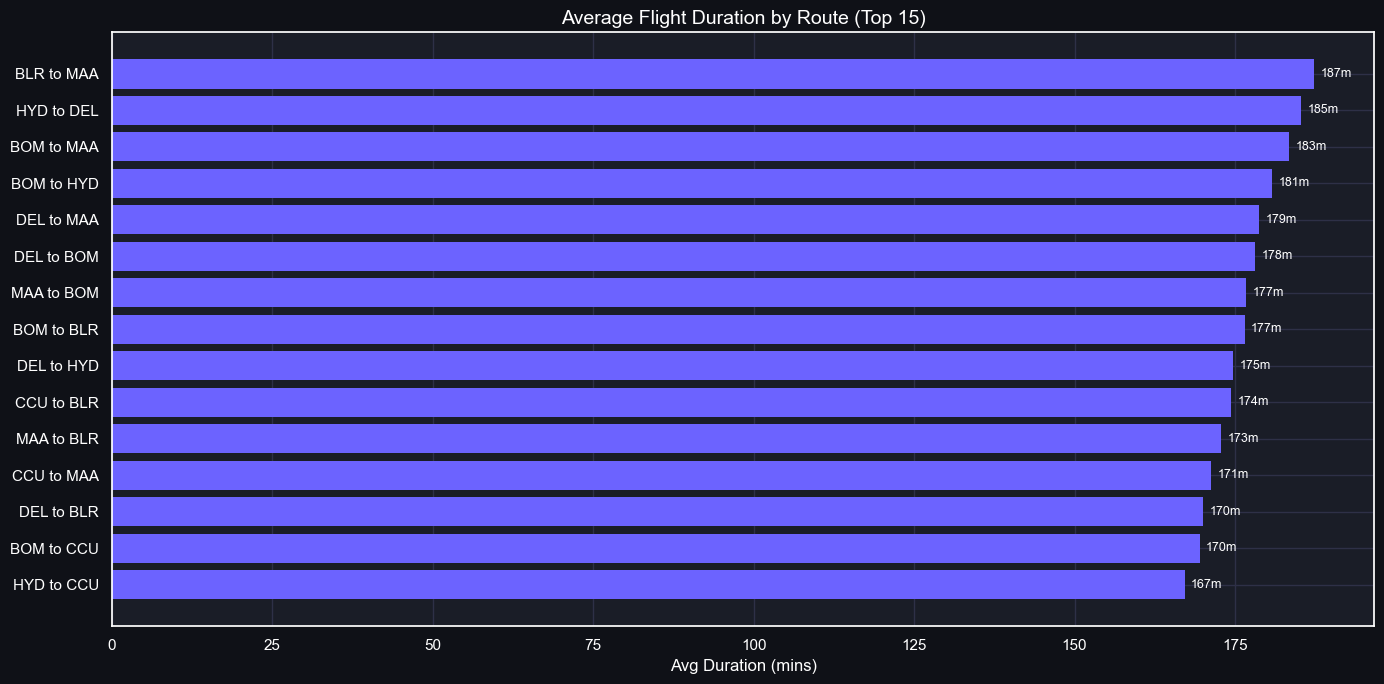

In [18]:
# ─── 5.2  Average Duration by Route (Top 15) ─────────────────────────────────
top_routes = avg_by_route.head(15)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(top_routes['route'][::-1], top_routes['avg_duration_mins'][::-1],
               color='#6C63FF', edgecolor='none')
ax.set_xlabel('Avg Duration (mins)')
ax.set_title('Average Flight Duration by Route (Top 15)', fontsize=14)
for bar, val in zip(bars, top_routes['avg_duration_mins'][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}m', va='center', color='white', fontsize=9)
plt.tight_layout()
plt.savefig('../data/cleaned/viz_avg_duration_route.png', dpi=150, bbox_inches='tight')
plt.show()

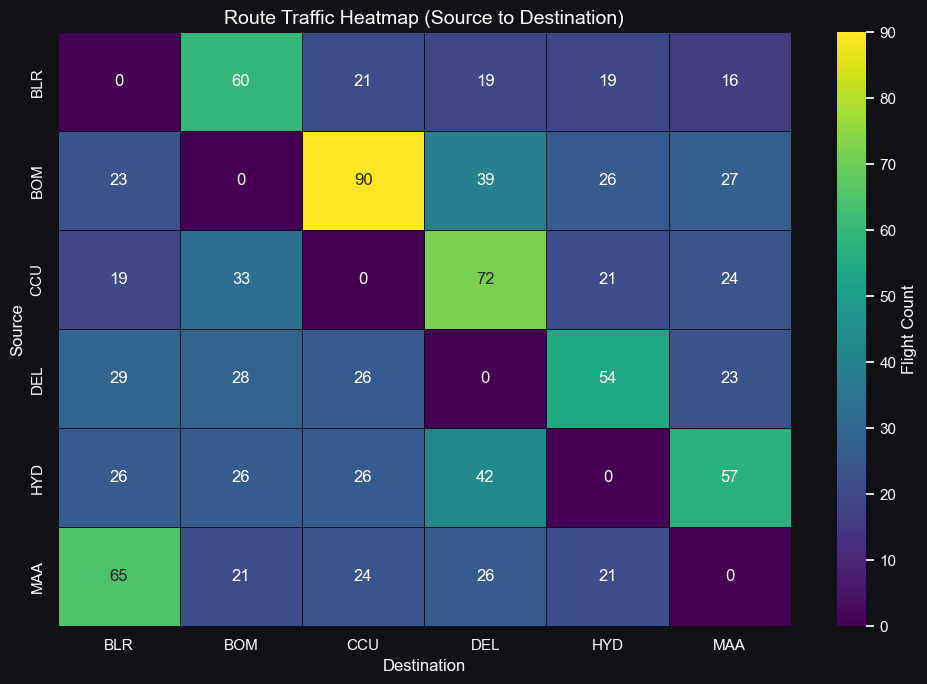

In [19]:
# ─── 5.3  Route Traffic Heatmap ──────────────────────────────────────────────
pivot = flights.pivot_table(index='source', columns='destination',
                             values='flight_id', aggfunc='count', fill_value=0)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='d', cmap='viridis', ax=ax,
            linewidths=0.5, linecolor='#0f1117', cbar_kws={'label': 'Flight Count'})
ax.set_title('Route Traffic Heatmap (Source to Destination)', fontsize=14)
ax.set_xlabel('Destination')
ax.set_ylabel('Source')
plt.tight_layout()
plt.savefig('../data/cleaned/viz_route_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

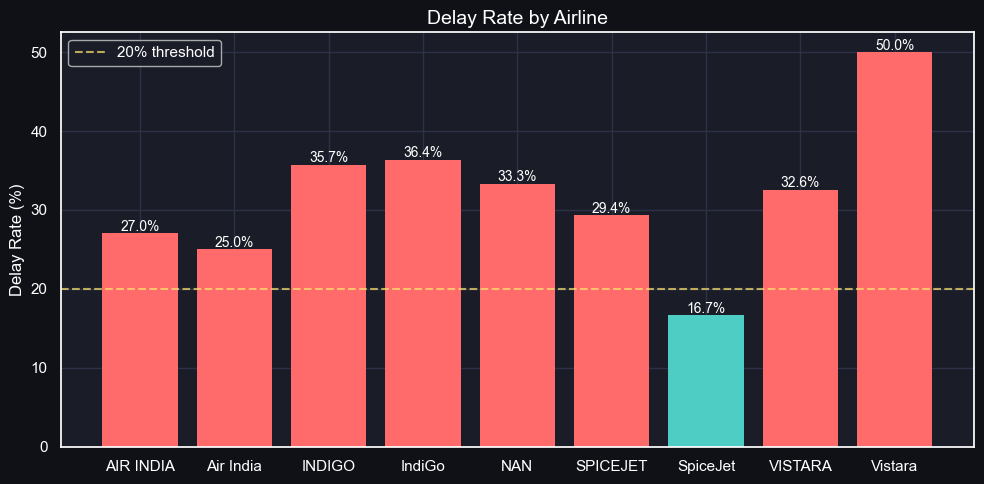

In [20]:
# ─── 5.4  Delay Rate by Airline ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
COLORS2 = ['#FF6B6B' if r > 20 else '#4ECDC4' for r in delay_summary['delay_rate_%']]
bars = ax.bar(delay_summary['airline'], delay_summary['delay_rate_%'],
              color=COLORS2, edgecolor='none')
ax.axhline(y=20, linestyle='--', color='#FFE66D', alpha=0.7, label='20% threshold')
ax.set_ylabel('Delay Rate (%)')
ax.set_title('Delay Rate by Airline', fontsize=14)
ax.legend()
for bar, val in zip(bars, delay_summary['delay_rate_%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', color='white', fontsize=10)
plt.tight_layout()
plt.savefig('../data/cleaned/viz_delay_rate.png', dpi=150, bbox_inches='tight')
plt.show()

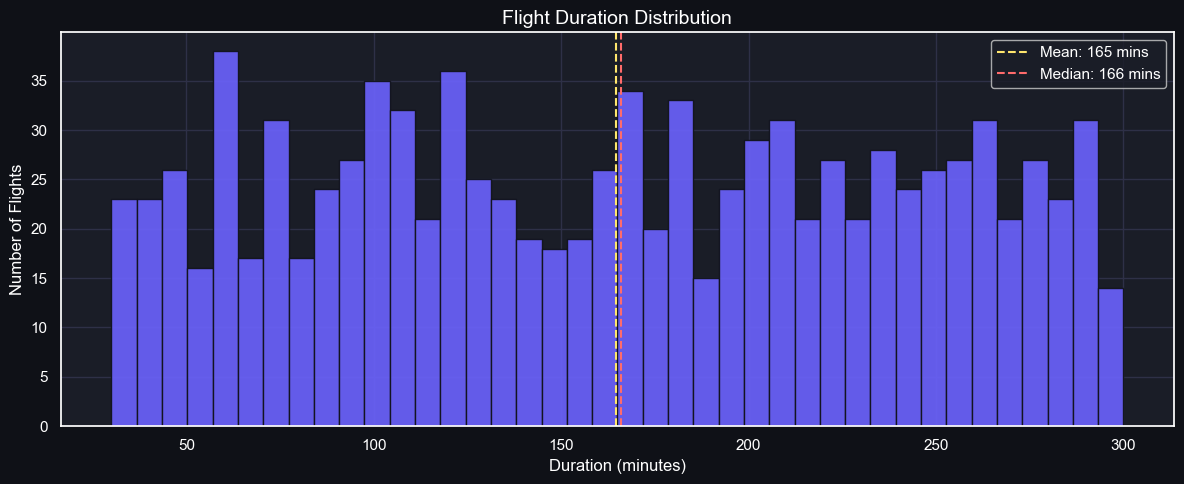

In [21]:
# ─── 5.5  Flight Duration Distribution ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(flights['duration_mins'], bins=40, color='#6C63FF', edgecolor='#0f1117', alpha=0.9)
ax.axvline(flights['duration_mins'].mean(), color='#FFE66D', linestyle='--',
           label=f'Mean: {flights["duration_mins"].mean():.0f} mins')
ax.axvline(flights['duration_mins'].median(), color='#FF6B6B', linestyle='--',
           label=f'Median: {flights["duration_mins"].median():.0f} mins')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Number of Flights')
ax.set_title('Flight Duration Distribution', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('../data/cleaned/viz_duration_dist.png', dpi=150, bbox_inches='tight')
plt.show()

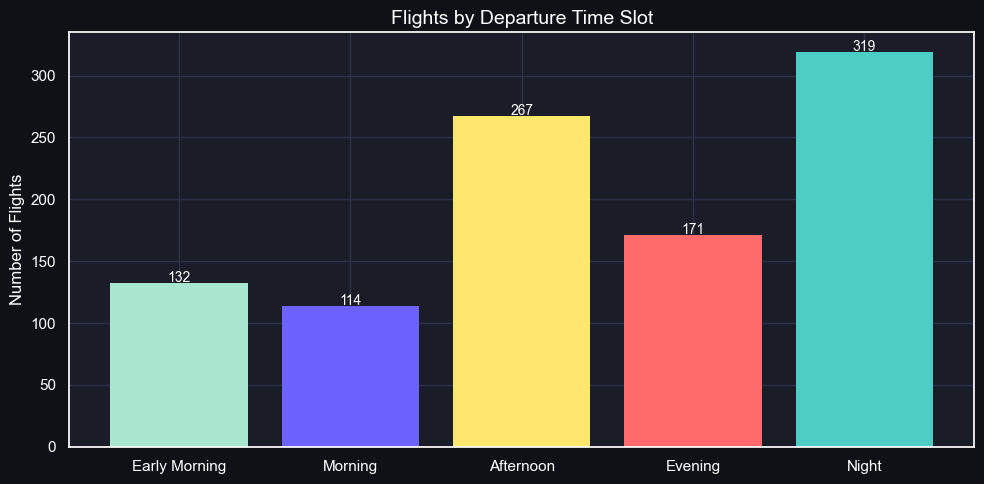

In [22]:
# ─── 5.6  Departure Slot Analysis ────────────────────────────────────────────
slot_order = ['Early Morning', 'Morning', 'Afternoon', 'Evening', 'Night']
slot_data = slot_traffic.set_index('departure_slot').reindex(slot_order).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(slot_data['departure_slot'], slot_data['flight_count'],
              color=['#A8E6CF','#6C63FF','#FFE66D','#FF6B6B','#4ECDC4'], edgecolor='none')
ax.set_ylabel('Number of Flights')
ax.set_title('Flights by Departure Time Slot', fontsize=14)
for bar, val in zip(bars, slot_data['flight_count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(val)), ha='center', color='white', fontsize=10)
plt.tight_layout()
plt.savefig('../data/cleaned/viz_departure_slots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 💾 Section 6 — Export Cleaned & Aggregated Data

In [23]:
# ─── 6.1  Export Cleaned DataFrames ──────────────────────────────────────────

# Cleaned flights (main fact table)
flights_export = flights[[
    'flight_id', 'airline', 'source', 'destination', 'route',
    'departure_time', 'arrival_time', 'duration_mins', 'duration_hhmm',
    'is_overnight', 'departure_slot', 'is_delayed',
    'departure_date', 'arrival_date', 'departure_hour'
]]
flights_export.to_csv(CLEANED_DIR / 'cleaned_flights.csv', index=False)
log.info('Exported cleaned_flights.csv: %d rows', len(flights_export))

# Masked passengers
pax_masked.to_csv(CLEANED_DIR / 'cleaned_passengers_masked.csv', index=False)
log.info('Exported cleaned_passengers_masked.csv: %d rows', len(pax_masked))

# Masked bookings
bk_masked.to_csv(CLEANED_DIR / 'cleaned_bookings_masked.csv', index=False)
log.info('Exported cleaned_bookings_masked.csv: %d rows', len(bk_masked))

# Payments
payments.to_csv(CLEANED_DIR / 'cleaned_payments.csv', index=False)
log.info('Exported cleaned_payments.csv: %d rows', len(payments))

print('✅ Cleaned data exported to /data/cleaned/')

23:20:25 | INFO | Exported cleaned_flights.csv: 1003 rows


23:20:25 | INFO | Exported cleaned_passengers_masked.csv: 1039 rows


23:20:25 | INFO | Exported cleaned_bookings_masked.csv: 1000 rows


23:20:25 | INFO | Exported cleaned_payments.csv: 922 rows


✅ Cleaned data exported to /data/cleaned/


In [24]:
# ─── 6.2  Export KPI Aggregations ────────────────────────────────────────────

route_traffic.to_csv(AGG_DIR / 'kpi_route_traffic.csv', index=False)
avg_by_airline.to_csv(AGG_DIR / 'kpi_avg_duration_by_airline.csv', index=False)
avg_by_route.to_csv(AGG_DIR / 'kpi_avg_duration_by_route.csv', index=False)
airline_dist.to_csv(AGG_DIR / 'kpi_airline_distribution.csv', index=False)
delay_summary.to_csv(AGG_DIR / 'kpi_delay_summary.csv', index=False)
revenue_by_airline.to_csv(AGG_DIR / 'kpi_revenue_by_airline.csv', index=False)
slot_traffic.to_csv(AGG_DIR / 'kpi_departure_slots.csv', index=False)
booking_status.to_csv(AGG_DIR / 'kpi_booking_status.csv', index=False)
payment_method_dist.to_csv(AGG_DIR / 'kpi_payment_methods.csv', index=False)

print('✅ KPI aggregations exported to /data/aggregated/')
for f in sorted(AGG_DIR.iterdir()):
    print(f'   {f.name}')

✅ KPI aggregations exported to /data/aggregated/
   kpi_airline_distribution.csv
   kpi_avg_duration_by_airline.csv
   kpi_avg_duration_by_route.csv
   kpi_booking_status.csv
   kpi_delay_summary.csv
   kpi_departure_slots.csv
   kpi_payment_methods.csv
   kpi_revenue_by_airline.csv
   kpi_route_traffic.csv


In [25]:
# ─── 6.3  Master Joined Dataset for Power BI ─────────────────────────────────
#
# One wide denormalized table that Power BI can consume directly
# (bookings + flights + payments — no PII)

master = (
    bk_masked
    .merge(flights_export, on='flight_id', how='left')
    .merge(payments[['booking_id','amount','payment_method']], on='booking_id', how='left')
)

master.to_csv(CLEANED_DIR / 'master_dataset.csv', index=False)
log.info('Exported master_dataset.csv: %d rows x %d cols', *master.shape)

print(f'✅ Master dataset: {master.shape[0]} rows x {master.shape[1]} columns')
master.head(3)

23:20:25 | INFO | Exported master_dataset.csv: 1316 rows x 25 cols


✅ Master dataset: 1316 rows x 25 columns


,booking_id,passenger_id,flight_id,booking_date,status,seat_number,passport_hash,emg_phone_hash,emg_name_masked,airline,...,duration_mins,duration_hhmm,is_overnight,departure_slot,is_delayed,departure_date,arrival_date,departure_hour,amount,payment_method
0,B1000,P1591,AI192,2025-06-14 11:37:36.951,CANCELLED,3D,652f4788875e3ce65d9e1ce2b135153e78c4ad42ec5df0...,5f330beaaf394f963e9937d2148f8fdf89051d4310f769...,I***,AIR INDIA,...,299.0,4h 59m,1.0,Night,1.0,2026-04-20,2026-04-21,23.0,NaN,NaN
1,B1001,P1803,6F026,2025-11-02 11:37:36.951,CANCELLED,18A,6f9874391801195a95bcd1673e3ca0d5f3ecf02f9d0600...,208cc59f5d3e2fd6eb6551e58530942ecb812cbf26b35b...,A***,INDIGO,...,267.0,4h 27m,1.0,Night,1.0,2026-04-20,2026-04-21,22.0,NaN,NaN
2,B1002,P1083,SJ010,2025-08-25 11:37:36.951,CANCELLED,30C,442dd481c3c4f8ec14493472239f5f80b4954201229041...,04bc4fe0633286fb857dd4949a18ff32ac5fb892486935...,U***,SPICEJET,...,174.0,2h 54m,1.0,Night,0.0,2026-04-20,2026-04-21,23.0,6087.22,UPI


---
## 📋 Section 7 — Pipeline Summary

In [26]:
# ─── 7.1  Final Pipeline Summary ─────────────────────────────────────────────
print('=' * 65)
print('       ASG AIRLINES — DATA PIPELINE EXECUTION SUMMARY')
print('=' * 65)
print(f'  Timestamp         : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print()
print('  RAW DATA INGESTED')
print(f'    Flights          : {len(raw["flights"]):>6} rows')
print(f'    Bookings         : {len(raw["bookings"]):>6} rows')
print(f'    Passengers       : {len(raw["passengers"]):>6} rows')
print(f'    Payments         : {len(raw["payments"]):>6} rows')
print()
print('  AFTER CLEANING')
print(f'    Flights          : {len(flights):>6} rows')
print(f'    Bookings (masked): {len(bk_masked):>6} rows')
print(f'    Passengers (mask): {len(pax_masked):>6} rows')
print(f'    Payments         : {len(payments):>6} rows')
print()
print('  KEY KPIs')
print(f'    Avg flight duration   : {flights["duration_mins"].mean():>6.1f} mins')
print(f'    Overnight flights     : {flights["is_overnight"].sum():>6}')
print(f'    Delayed flights       : {flights["is_delayed"].sum():>6}')
print(f'    Overall delay rate    : {flights["is_delayed"].mean()*100:>6.1f}%')
print(f'    Unique routes         : {flights["route"].nunique():>6}')
print(f'    Active airlines       : {flights["airline"].nunique():>6}')
print()
print('  PII FIELDS MASKED')
print('    aadhaar_id, email, phone (SHA-256)')
print('    passport_number, emg_phone (SHA-256)')
print('    first/last names (pseudonymised)')
print('    date_of_birth (year only retained)')
print()
print('  OUTPUT FILES')
print('    data/cleaned/cleaned_flights.csv')
print('    data/cleaned/cleaned_passengers_masked.csv')
print('    data/cleaned/cleaned_bookings_masked.csv')
print('    data/cleaned/cleaned_payments.csv')
print('    data/cleaned/master_dataset.csv')
print('    data/aggregated/kpi_*.csv  (9 KPI files)')
print('=' * 65)
print('  Pipeline completed successfully!')
print('=' * 65)

       ASG AIRLINES — DATA PIPELINE EXECUTION SUMMARY
  Timestamp         : 2026-09-05 23:20:25

  RAW DATA INGESTED
    Flights          :   1020 rows
    Bookings         :   1000 rows
    Passengers       :   1039 rows
    Payments         :   1000 rows

  AFTER CLEANING
    Flights          :   1003 rows
    Bookings (masked):   1000 rows
    Passengers (mask):   1039 rows
    Payments         :    922 rows

  KEY KPIs
    Avg flight duration   :  164.6 mins
    Overnight flights     :    122
    Delayed flights       :    314
    Overall delay rate    :   31.3%
    Unique routes         :     30
    Active airlines       :      9

  PII FIELDS MASKED
    aadhaar_id, email, phone (SHA-256)
    passport_number, emg_phone (SHA-256)
    first/last names (pseudonymised)
    date_of_birth (year only retained)

  OUTPUT FILES
    data/cleaned/cleaned_flights.csv
    data/cleaned/cleaned_passengers_masked.csv
    data/cleaned/cleaned_bookings_masked.csv
    data/cleaned/cleaned_payments.c